# 01 — GEE Hello World + CHIRPS proof-of-loop

**Week 1 goal:** Prove the entire **GEE → Drive** pipeline works before building anything bigger.

By the end of this notebook you will have:
1. Verified the project grid shape
2. Visualised Botswana's boundary and CHIRPS rainfall on an interactive map
3. Exported a monthly CHIRPS GeoTIFF to Google Drive (closes the loop)
4. Read it back and confirmed it aligns to the project grid

Run **top to bottom** in Google Colab. You need:
- A free Earth Engine account: https://earthengine.google.com/signup/
- A Cloud project ID (create one at https://code.earthengine.google.com → Cloud project)

In [ ]:
# Install the few packages Colab doesn't pre-ship
!pip install -q geemap rioxarray

# Make the project library importable (assumes you cloned the repo at /content/botswana-drought-flood)
# If you haven't cloned yet:
#   !git clone https://github.com/<you>/botswana-drought-flood.git /content/botswana-drought-flood
import sys
sys.path.insert(0, '/content/botswana-drought-flood/src')
print('Path set.')

In [ ]:
import ee, geemap
from ee import oauth as _oauth

# Generate a fresh auth flow (PKCE — the code_verifier must match the URL we generate here)
_flow = _oauth.Flow('notebook')

print("Step 1 — open this URL in your browser and approve access:")
print()
print(_flow.auth_url)
print()

# input() shows a text box in VS Code and browser Jupyter
_code = input("Step 2 — paste the authorization code here: ")

ee.Authenticate(authorization_code=_code.strip(), code_verifier=_flow.code_verifier)
ee.Initialize(project='infosys-drought-prediction')
print('Earth Engine ready.')

---
## Step 1 — Verify the common grid

Every variable in this project lives on the same 0.05° grid, aligned to CHIRPS.
"Aligned" means CHIRPS never needs resampling — it IS the grid. Every other
variable (MODIS, ERA5, SMAP) gets resampled TO this grid when we export.

This cell has no GEE dependency — it's pure Python, so you can run it offline.

In [ ]:
from botswana_ds.grid import make_grid

g = make_grid()
H, W = g.shape

print(f'Grid shape        : {H} rows (N→S) × {W} cols (W→E)')
print(f'Total pixels      : {H * W:,}')
print(f'Resolution        : {g.res}° ≈ 5.5 km per pixel')
print(f'Lon range (W→E)   : {g.lons[0]:.2f}° to {g.lons[-1]:.2f}°  (Botswana: ~20°E–29.4°E)')
print(f'Lat range (N→S)   : {g.lats[0]:.2f}° to {g.lats[-1]:.2f}°  (Botswana: ~17.8°S–26.9°S)')

---
## Step 2 — Show Botswana + CHIRPS on an interactive map

We use `geemap` to inspect GEE data directly in the notebook without downloading anything.

We'll look at January 2016 — the start of a major El Niño drought year in southern Africa.
Expect to see **low rainfall** (pale/yellow) over the Kalahari in the south-west and
**higher rainfall** (green/dark-green) in the Chobe/Okavango region in the north.

In [ ]:
import ee, geemap
ee.Initialize(project='infosys-drought-prediction')

from botswana_ds.gee.export import botswana_geometry, monthly_chirps

aoi = botswana_geometry()
chirps_2016 = monthly_chirps('2016-01-01', '2017-01-01', region=aoi)
jan_2016 = chirps_2016.first()

vis = {'min': 0, 'max': 150, 'palette': ['#ffffcc', '#78c679', '#238443', '#004529']}

m = geemap.Map(center=[-22, 24], zoom=5)
m.addLayer(aoi, {'color': 'red'}, 'Botswana boundary')
m.addLayer(jan_2016, vis, 'CHIRPS rain Jan 2016 (mm)')
m.add_colorbar(vis, label='Rainfall (mm/month)')
m

---
## Step 3 — Export January 2016 to Google Drive

This kicks off an asynchronous **GEE batch task** that writes
`chirps_2016_01.tif` to `My Drive/BotswanaDroughtFloodSet/`.

After running this cell:
1. Go to https://code.earthengine.google.com → **Tasks** tab
2. Wait for status to flip from `RUNNING` to `COMPLETED` (~1–3 minutes)
3. Then run Step 4 to read it back

Key export parameters:
- `scale=5566` m ≈ 0.05° — matches the project grid exactly
- `crs='EPSG:4326'` — plain lat/lon, consistent with all other exports
- `maxPixels=1e10` — safety cap; a single Botswana month is far below this

In [ ]:
import ee
ee.Initialize(project='infosys-drought-prediction')

from botswana_ds.gee.export import botswana_geometry, monthly_chirps, _export_region
from botswana_ds.grid import GEE_CRS_TRANSFORM, GEE_DIMENSIONS

aoi = botswana_geometry()
jan_2016 = monthly_chirps('2016-01-01', '2017-01-01', region=aoi).first()

task = ee.batch.Export.image.toDrive(
    image=jan_2016.rename('precipitation'),
    description='chirps_2016_01',
    folder='BotswanaDroughtFloodSet',
    fileNamePrefix='chirps_2016_01',
    region=_export_region(),
    crsTransform=GEE_CRS_TRANSFORM,
    dimensions=GEE_DIMENSIONS,
    crs='EPSG:4326',
    maxPixels=1e10,
)
task.start()
print(f'Export started — task id: {task.id}')
print('Monitor at https://code.earthengine.google.com → Tasks')


---
## Step 4 — Read back and verify alignment

**Run this cell only after the export shows COMPLETED in the Tasks tab.**

We mount Google Drive, open the GeoTIFF with `rioxarray`, and confirm:
- Shape matches the project grid
- CRS is EPSG:4326
- Values are physically reasonable (non-negative rainfall)

If the shape is off by 1 pixel in either dimension, that's a rounding artefact
from GEE snapping to the nearest pixel edge — harmless.

=== Exported GeoTIFF ===
Shape (bands, rows, cols) : (1, 182, 188)
CRS                       : EPSG:4326
Spatial resolution        : 0.05000°
Value range               : 9.0 to 196.3 mm
Valid (non-NaN) pixels    : 20,643

=== Grid alignment check ===
Expected (H, W)  : 182 × 188
Exported (H, W)  : 182 × 188
Match             : PASS


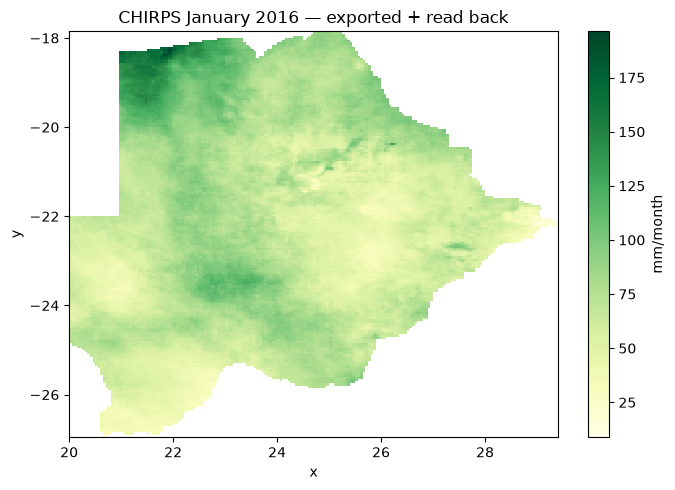

In [2]:
# Download chirps_2016_01.tif from Google Drive (My Drive → BotswanaDroughtFloodSet/)
# and place it at:  botswana-drought-flood/data/chirps_2016_01.tif
# Then run this cell.

import rioxarray as rxr
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from botswana_ds.grid import make_grid

tif = Path('..') / 'data' / 'chirps_2016_01.tif'
if not tif.exists():
    raise FileNotFoundError(
        f"Not found: {tif}\n"
        "Download chirps_2016_01.tif from Google Drive → BotswanaDroughtFloodSet/ "
        "and save it to the data/ folder in this repo."
    )

da = rxr.open_rasterio(tif, masked=True)

print('=== Exported GeoTIFF ===')
print(f'Shape (bands, rows, cols) : {da.shape}')
print(f'CRS                       : {da.rio.crs}')
print(f'Spatial resolution        : {abs(float(da.rio.resolution()[0])):.5f}°')
print(f'Value range               : {float(da.min()):.1f} to {float(da.max()):.1f} mm')
print(f'Valid (non-NaN) pixels    : {int((~np.isnan(da.values)).sum()):,}')

g = make_grid()
H, W = g.shape
print(f'\n=== Grid alignment check ===')
print(f'Expected (H, W)  : {H} × {W}')
print(f'Exported (H, W)  : {da.shape[1]} × {da.shape[2]}')
ok = (da.shape[1] == H) and (da.shape[2] == W)
print(f'Match             : {"PASS" if ok else "FAIL — check bbox / crsTransform params"}')

fig, ax = plt.subplots(figsize=(7, 5))
da[0].plot(ax=ax, cmap='YlGn', cbar_kwargs={'label': 'mm/month'})
ax.set_title('CHIRPS January 2016 — exported + read back')
plt.tight_layout()
plt.show()


---
## Step 5 — Export the land mask (bonus)

The land mask is a single-band GeoTIFF (1 = inside Botswana, 0 = outside).
We will use it in PyTorch to exclude pixels outside the border from the loss.

This is fast — it just rasterises the GAUL polygon, no image collection involved.

In [ ]:
from botswana_ds.gee.export import export_land_mask

task_mask = export_land_mask(folder='BotswanaDroughtFloodSet')
print(f'Land mask export started — task id: {task_mask.id}')
print('Check the Tasks tab; file will be land_mask.tif in BotswanaDroughtFloodSet/')

---
## Week 1 success criteria

| Check | Expected result |
|-------|-----------------|
| Grid shape prints | ~182 rows × 188 cols (exact values depend on bbox rounding) |
| Botswana boundary renders | Red outline on geemap |
| CHIRPS Jan 2016 map | Dry (pale) Kalahari south-west, wetter north |
| Export task starts | Task id printed, shows in GEE Tasks tab |
| Read-back shape check | PASS (±1 pixel) |
| Values sensible | Range 0–~200 mm, all non-negative |

**All boxes ticked? You're ready for Week 2.**

Next: `02_export_pipeline.ipynb` — loop `export_variable_to_drive()` over all 9
drought-core channels for the full 2003–2024 period.